Prerequisits

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

Parameters

In [ ]:
RGB_IMG_HEIGHT = 224
RGB_IMG_WIDTH  = 224
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE

COMBINER_EPOCHS = 300
COMBINER_LR = 1e-3
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

Paths to datasets and models

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")

METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_ingredients_split_metadata.csv")

MODEL3_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only")
MODEL12_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_12_ViT_overhead_RGB_plus_actual_ingredients")
MODEL12_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = MODEL12_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

MODEL3_FINAL_MODEL = MODEL3_DIR / "final_model.keras"

Loading meta data

In [ ]:
df = pd.read_csv(METADATA_CSV)

print("Loaded file:", METADATA_CSV)
print("Shape before processing:", df.shape)
print("Columns:", df.columns.tolist()[:40], "...")
display(df.head())

Loaded file: /content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_ingredients_split_metadata.csv
Shape before processing: (3262, 205)
Columns: ['dish_id', 'total_mass', 'total_carb', 'split', 'source_cafe', 'num_ingredients', 'ingredient_list_str', 'ingr_almonds', 'ingr_apple', 'ingr_artichokes', 'ingr_arugula', 'ingr_asparagus', 'ingr_avocado', 'ingr_baby_carrots', 'ingr_bacon', 'ingr_bagels', 'ingr_banana_with_peel', 'ingr_basil', 'ingr_beef', 'ingr_beets', 'ingr_bell_peppers', 'ingr_berries', 'ingr_black_beans', 'ingr_blackberries', 'ingr_blue_cheese', 'ingr_blueberries', 'ingr_bok_choy', 'ingr_bread', 'ingr_broccoli', 'ingr_brown_rice', 'ingr_brown_sugar', 'ingr_brownies', 'ingr_brussels_sprouts', 'ingr_bulgur', 'ingr_butter', 'ingr_buttermilk', 'ingr_cabbage', 'ingr_caesar_dressing', 'ingr_caesar_salad', 'ingr_cantaloupe'] ...


,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,...,ingr_wheat_berry,ingr_wheat_bread,ingr_white_beans,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini
0,dish_1556575327,152.0,10.618,test,cafe1,3,brussels_sprouts|celery|olives,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,dish_1557861216,1.0,0.000,test,cafe1,1,plate_only,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,dish_1557862345,63.0,0.000,test,cafe1,1,chicken,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,dish_1557862696,77.0,3.850,test,cafe1,1,cauliflower,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,dish_1557862738,118.0,0.000,test,cafe1,1,steak,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
required_cols = ["dish_id", "total_carb", "split", "source_cafe"]
missing_cols = [c for c in required_cols if c not in df.columns]
if len(missing_cols) > 0:
    raise ValueError(f"Missing required columns: {missing_cols}")

ingredient_cols = [c for c in df.columns if c.startswith("ingr_")]

if len(ingredient_cols) == 0:
    raise ValueError("No ingredient columns found. Expected columns starting with 'ingr_'.")

print("Number of ingredient columns:", len(ingredient_cols))
print("First 20 ingredient columns:", ingredient_cols[:20])

Number of ingredient columns: 198
First 20 ingredient columns: ['ingr_almonds', 'ingr_apple', 'ingr_artichokes', 'ingr_arugula', 'ingr_asparagus', 'ingr_avocado', 'ingr_baby_carrots', 'ingr_bacon', 'ingr_bagels', 'ingr_banana_with_peel', 'ingr_basil', 'ingr_beef', 'ingr_beets', 'ingr_bell_peppers', 'ingr_berries', 'ingr_black_beans', 'ingr_blackberries', 'ingr_blue_cheese', 'ingr_blueberries', 'ingr_bok_choy']


Loading image paths

In [ ]:
df["dish_id"] = df["dish_id"].astype(str).str.strip()

df["rgb_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / str(d) / "overhead" / "rgb.png")
)

df["rgb_exists"] = df["rgb_path"].apply(lambda p: Path(p).exists())

print("Missing RGB images:", (~df["rgb_exists"]).sum())

Missing RGB images: 0


In [ ]:
def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except Exception:
        return -1

df["rgb_size"] = df["rgb_path"].apply(file_size_or_minus1)

print("Empty RGB files:", (df["rgb_size"] <= 0).sum())

df = df[
    (df["rgb_exists"]) &
    (df["rgb_size"] > 0)
].copy()

print("\nRemaining samples after RGB filtering:")
print(df["split"].value_counts(dropna=False))
print("Total remaining:", len(df))
display(df.head())

Empty RGB files: 0

Remaining samples after RGB filtering:
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total remaining: 3262


,dish_id,total_mass,total_carb,split,source_cafe,num_ingredients,ingredient_list_str,ingr_almonds,ingr_apple,ingr_artichokes,...,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini,rgb_path,rgb_exists,rgb_size
0,dish_1556575327,152.0,10.618,test,cafe1,3,brussels_sprouts|celery|olives,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,548259
1,dish_1557861216,1.0,0.000,test,cafe1,1,plate_only,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,353804
2,dish_1557862345,63.0,0.000,test,cafe1,1,chicken,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,407501
3,dish_1557862696,77.0,3.850,test,cafe1,1,cauliflower,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,391780
4,dish_1557862738,118.0,0.000,test,cafe1,1,steak,0,0,0,...,0,0,0,0,0,0,0,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412017


Splitting into training / validation and testing dataset

In [ ]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df   = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df  = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


In [ ]:
train_csv = PREP_DIR / "train_model12_rgb_ingr.csv"
val_csv   = PREP_DIR / "val_model12_rgb_ingr.csv"
test_csv  = PREP_DIR / "test_model12_rgb_ingr.csv"
full_csv  = PREP_DIR / "full_model12_rgb_ingr.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)
df.to_csv(full_csv, index=False)

print("Saved:")
print(train_csv)
print(val_csv)
print(test_csv)
print(full_csv)

Saved:
/content/drive/MyDrive/Speciale/Models/Model_12_ViT_overhead_RGB_plus_actual_ingredients/prep_files/train_model12_rgb_ingr.csv
/content/drive/MyDrive/Speciale/Models/Model_12_ViT_overhead_RGB_plus_actual_ingredients/prep_files/val_model12_rgb_ingr.csv
/content/drive/MyDrive/Speciale/Models/Model_12_ViT_overhead_RGB_plus_actual_ingredients/prep_files/test_model12_rgb_ingr.csv
/content/drive/MyDrive/Speciale/Models/Model_12_ViT_overhead_RGB_plus_actual_ingredients/prep_files/full_model12_rgb_ingr.csv


Loading in RGB images

In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=RGB_IMG_HEIGHT,
        target_width=RGB_IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_and_label(rgb_path, label):
    rgb = load_rgb_image(rgb_path)
    label = tf.cast(label, tf.float32)
    return {"rgb_input": rgb}, label


def make_rgb_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    rgb_paths = dataframe["rgb_path"].astype(str).values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(load_rgb_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

In [ ]:
train_rgb_dataset = make_rgb_dataset(train_df, batch_size=BATCH_SIZE, shuffle=False)
val_rgb_dataset   = make_rgb_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_rgb_dataset  = make_rgb_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

for batch_inputs, batch_labels in train_rgb_dataset.take(1):
    print("Input keys:", batch_inputs.keys())
    print("RGB shape:", batch_inputs["rgb_input"].shape)
    print("Labels shape:", batch_labels.shape)

Input keys: dict_keys(['rgb_input'])
RGB shape: (16, 224, 224, 3)
Labels shape: (16,)


Loading RGB trained transformer

In [ ]:
if MODEL3_FINAL_MODEL.exists():
    print("Loading RGB transformer from:", MODEL3_FINAL_MODEL)
    rgb_carb_model = keras.models.load_model(MODEL3_FINAL_MODEL)
else:
    raise FileNotFoundError(f"Could not find Model 3 V3 model at: {MODEL3_FINAL_MODEL}")

Loading RGB transformer from: /content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only/final_model.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 896 variables whereas the saved optimizer has 886 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
rgb_carb_model.summary()

Model: "rgb_only_dino_vit_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_image_converter          │ (None, 224, 224, 3)    │             0 │
│ (DINOV2ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_backbone                 │ (None, 257, 1024)      │   304,631,808 │
│ (DINOV2Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 257, 1024)      │         2,048 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_pool                      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 911,932,549 (3.40 GB)

 Trainable params: 303,509,889 (1.13 GB)

 Non-trainable params: 1,402,880 (5.35 MB)

 Optimizer params: 607,019,780 (2.26 GB)

Generating carbohydrate predictions

In [ ]:
train_rgb_carb_preds = rgb_carb_model.predict(train_rgb_dataset, verbose=1).reshape(-1)
val_rgb_carb_preds   = rgb_carb_model.predict(val_rgb_dataset, verbose=1).reshape(-1)
test_rgb_carb_preds  = rgb_carb_model.predict(test_rgb_dataset, verbose=1).reshape(-1)

print("Train preds shape:", train_rgb_carb_preds.shape)
print("Val preds shape:  ", val_rgb_carb_preds.shape)
print("Test preds shape: ", test_rgb_carb_preds.shape)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)


151/152 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


152/152 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step
Train preds shape: (2421,)
Val preds shape:   (334,)
Test preds shape:  (507,)


Building combiner dataframe

In [ ]:
base_cols = ["dish_id", "total_carb", "split", "source_cafe"] + ingredient_cols

train_combiner_df = train_df[base_cols].copy().reset_index(drop=True)
val_combiner_df   = val_df[base_cols].copy().reset_index(drop=True)
test_combiner_df  = test_df[base_cols].copy().reset_index(drop=True)

train_combiner_df["rgb_carb_pred"] = train_rgb_carb_preds
val_combiner_df["rgb_carb_pred"]   = val_rgb_carb_preds
test_combiner_df["rgb_carb_pred"]  = test_rgb_carb_preds

display(train_combiner_df.head())

,dish_id,total_carb,split,source_cafe,ingr_almonds,ingr_apple,ingr_artichokes,ingr_arugula,ingr_asparagus,ingr_avocado,...,ingr_wheat_bread,ingr_white_beans,ingr_white_rice,ingr_white_wine,ingr_wild_rice,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini,rgb_carb_pred
0,dish_1556572657,2.268,train,cafe1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.041218
1,dish_1556573514,1.219,train,cafe1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1.584430
2,dish_1556575014,3.906,train,cafe1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,3.690660
3,dish_1556575083,5.760,train,cafe1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5.872280
4,dish_1556575124,0.952,train,cafe1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0.847786


In [ ]:
train_combiner_csv = MODEL12_DIR / "train_combiner_features_rgb_ingredients.csv"
val_combiner_csv   = MODEL12_DIR / "val_combiner_features_rgb_ingredients.csv"
test_combiner_csv  = MODEL12_DIR / "test_combiner_features_rgb_ingredients.csv"

train_combiner_df.to_csv(train_combiner_csv, index=False)
val_combiner_df.to_csv(val_combiner_csv, index=False)
test_combiner_df.to_csv(test_combiner_csv, index=False)

print("Saved combiner feature CSVs.")

Saved combiner feature CSVs.


Preparing neural combiner input

In [ ]:
X_train_rgb = train_combiner_df[["rgb_carb_pred"]].values.astype("float32")
X_val_rgb   = val_combiner_df[["rgb_carb_pred"]].values.astype("float32")
X_test_rgb  = test_combiner_df[["rgb_carb_pred"]].values.astype("float32")

X_train_ingr = train_combiner_df[ingredient_cols].values.astype("float32")
X_val_ingr   = val_combiner_df[ingredient_cols].values.astype("float32")
X_test_ingr  = test_combiner_df[ingredient_cols].values.astype("float32")

y_train = train_combiner_df["total_carb"].values.astype("float32")
y_val   = val_combiner_df["total_carb"].values.astype("float32")
y_test  = test_combiner_df["total_carb"].values.astype("float32")

In [ ]:
print("X_train_rgb:", X_train_rgb.shape)
print("X_train_ingr:", X_train_ingr.shape)
print("y_train:", y_train.shape)

X_train_rgb: (2421, 1)
X_train_ingr: (2421, 198)
y_train: (2421,)


In [ ]:
rgb_scaler = StandardScaler()

X_train_rgb_scaled = rgb_scaler.fit_transform(X_train_rgb).astype("float32")
X_val_rgb_scaled   = rgb_scaler.transform(X_val_rgb).astype("float32")
X_test_rgb_scaled  = rgb_scaler.transform(X_test_rgb).astype("float32")

joblib.dump(rgb_scaler, MODEL12_DIR / "rgb_scaler.joblib")
print("Saved RGB scaler.")

Saved RGB scaler.


Building network combiner

In [ ]:
rgb_input = keras.Input(shape=(1,), name="rgb_pred_input")
ingredient_input = keras.Input(shape=(len(ingredient_cols),), name="ingredient_input")

rgb_branch = layers.Dense(16, activation="relu")(rgb_input)
rgb_branch = layers.Dropout(0.1)(rgb_branch)

ingredient_branch = layers.Dense(128, activation="relu")(ingredient_input)
ingredient_branch = layers.Dropout(0.2)(ingredient_branch)
ingredient_branch = layers.Dense(64, activation="relu")(ingredient_branch)

fusion = layers.Concatenate()([rgb_branch, ingredient_branch])
fusion = layers.Dense(64, activation="relu")(fusion)
fusion = layers.Dropout(0.2)(fusion)
fusion = layers.Dense(32, activation="relu")(fusion)
output = layers.Dense(1, activation="linear", name="carb_output")(fusion)

model12 = keras.Model(
    inputs=[rgb_input, ingredient_input],
    outputs=output,
    name="model_12_neural_combiner"
)

In [ ]:
model12.compile(
    optimizer=keras.optimizers.Adam(learning_rate=COMBINER_LR),
    loss="mse",
    metrics=["mae", "mse"]
)

model12.summary()

Model: "model_12_neural_combiner"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ingredient_input    │ (None, 198)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rgb_pred_input      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     25,472 │ ingredient_input… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │         32 │ rgb_pred_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 128)       │          0 │ dense_1[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 16)        │          0 │ dense[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_25[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 80)        │          0 │ dropout_24[0][0], │
│ (Concatenate)       │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      5,184 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_26          │ (None, 64)        │          0 │ dense_3[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 32)        │      2,080 │ dropout_26[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ carb_output (Dense) │ (None, 1)         │         33 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,057 (160.38 KB)

 Trainable params: 41,057 (160.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model12_best_path = MODEL12_DIR / "best_model12_neural_combiner.weights.h5"

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(model12_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=200,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=150,
        min_lr=1e-6,
        verbose=1
    )
]

Training combiner

In [ ]:
history_model12 = model12.fit(
    {
        "rgb_pred_input": X_train_rgb_scaled,
        "ingredient_input": X_train_ingr
    },
    y_train,
    validation_data=(
        {
            "rgb_pred_input": X_val_rgb_scaled,
            "ingredient_input": X_val_ingr
        },
        y_val
    ),
    epochs=COMBINER_EPOCHS,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 582.0773 - mae: 17.2203 - mse: 582.0773
Epoch 1: val_loss improved from None to 164.62749, saving model to /content/drive/MyDrive/Speciale/Models/Model_12_ViT_overhead_RGB_plus_actual_ingredients/best_model12_neural_combiner.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_12_ViT_overhead_RGB_plus_actual_ingredients/best_model12_neural_combiner.weights.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 8s 47ms/step - loss: 645.4455 - mae: 14.5121 - mse: 645.4455 - val_loss: 164.6275 - val_mae: 10.3002 - val_mse: 164.6275 - learning_rate: 0.0010
Epoch 2/300
71/76 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 193.5352 - mae: 9.6549 - mse: 193.5352
Epoch 2: val_loss improved from 164.62749 to 109.43298, saving model to /content/drive/MyDrive/Speciale/Models/Model_12_ViT_overhead_RGB_plus_actual_ingredients/best_model12_neural_combiner.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Mo

In [ ]:
model12.load_weights(str(model12_best_path))
print("Loaded best Model 12 weights.")

Loaded best Model 12 weights.


Plotting training and validation curves

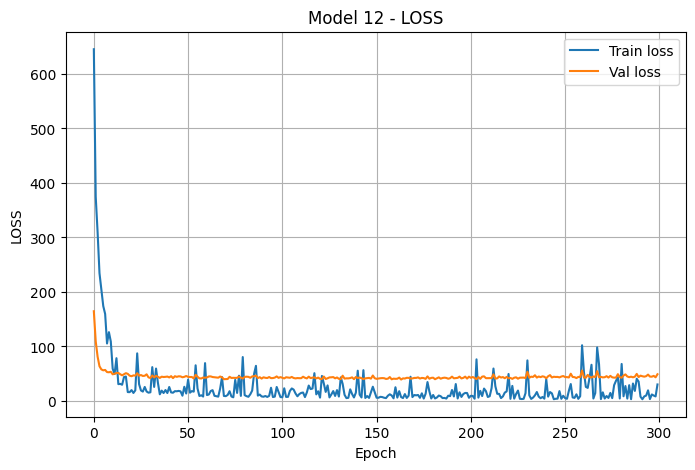

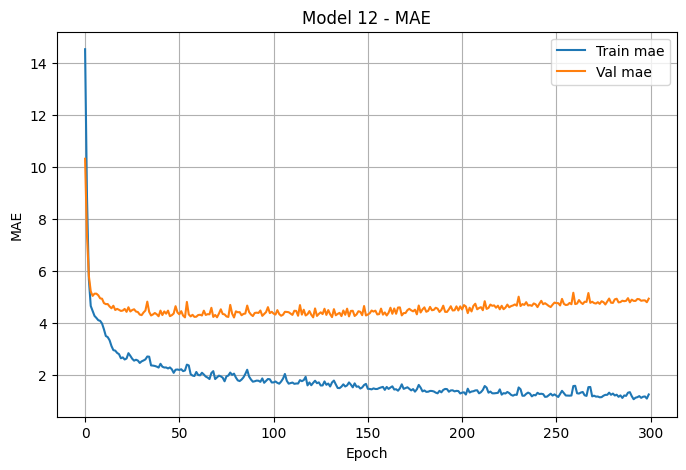

In [ ]:
for metric in ["loss", "mae"]:
    plt.figure(figsize=(8, 5))
    plt.plot(history_model12.history[metric], label=f"Train {metric}")
    plt.plot(history_model12.history[f"val_{metric}"], label=f"Val {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric.upper())
    plt.title(f"Model 12 - {metric.upper()}")
    plt.legend()
    plt.grid(True)
    plt.show()

Prediction on datasets

In [ ]:
train_preds = model12.predict(
    {
        "rgb_pred_input": X_train_rgb_scaled,
        "ingredient_input": X_train_ingr
    },
    verbose=1
).reshape(-1)

val_preds = model12.predict(
    {
        "rgb_pred_input": X_val_rgb_scaled,
        "ingredient_input": X_val_ingr
    },
    verbose=1
).reshape(-1)

test_preds = model12.predict(
    {
        "rgb_pred_input": X_test_rgb_scaled,
        "ingredient_input": X_test_ingr
    },
    verbose=1
).reshape(-1)

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


PMAE calculation helper

In [ ]:
def compute_pmae(y_true, y_pred, min_target=5.0):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    denom = np.maximum(np.abs(y_true), min_target)
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100.0)

Metrics

In [ ]:
def build_metric_row(model_name, y_train, train_pred, y_val, val_pred, y_test, test_pred):
    return {
        "model": model_name,

        "train_mae": float(mean_absolute_error(y_train, train_pred)),
        "train_mse": float(mean_squared_error(y_train, train_pred)),
        "train_rmse": float(np.sqrt(mean_squared_error(y_train, train_pred))),
        "train_r2": float(r2_score(y_train, train_pred)),
        "train_pmae": float(compute_pmae(y_train, train_pred)),

        "val_mae": float(mean_absolute_error(y_val, val_pred)),
        "val_mse": float(mean_squared_error(y_val, val_pred)),
        "val_rmse": float(np.sqrt(mean_squared_error(y_val, val_pred))),
        "val_r2": float(r2_score(y_val, val_pred)),
        "val_pmae": float(compute_pmae(y_val, val_pred)),

        "test_mae": float(mean_absolute_error(y_test, test_pred)),
        "test_mse": float(mean_squared_error(y_test, test_pred)),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, test_pred))),
        "test_r2": float(r2_score(y_test, test_pred)),
        "test_pmae": float(compute_pmae(y_test, test_pred)),
    }

In [ ]:
results = []

# RGB-only baseline
results.append(build_metric_row(
    "RGB_only_baseline",
    y_train, train_combiner_df["rgb_carb_pred"].values,
    y_val,   val_combiner_df["rgb_carb_pred"].values,
    y_test,  test_combiner_df["rgb_carb_pred"].values
))

# Model 12
results.append(build_metric_row(
    "Model_12_Neural_Combiner",
    y_train, train_preds,
    y_val,   val_preds,
    y_test,  test_preds
))

results_df = pd.DataFrame(results).sort_values("val_mae", ascending=True).reset_index(drop=True)
display(results_df)

,model,train_mae,train_mse,train_rmse,train_r2,train_pmae,val_mae,val_mse,val_rmse,val_r2,val_pmae,test_mae,test_mse,test_rmse,test_r2,test_pmae
0,Model_12_Neural_Combiner,1.019536,7.375067,2.715707,0.986181,9.589293,4.339498,39.312798,6.269992,0.827393,28.674328,4.887818,55.998119,7.483189,0.815509,29.533720
1,RGB_only_baseline,1.432568,6.344157,2.518761,0.988113,8.969028,4.529927,44.718330,6.687177,0.803660,29.068226,4.765221,57.263653,7.567275,0.811340,26.878647


Saving results

In [ ]:
results_csv = MODEL12_DIR / "model12_comparison.csv"
results_df.to_csv(results_csv, index=False)
print("Saved results to:", results_csv)

Saved results to: /content/drive/MyDrive/Speciale/Models/Model_12_ViT_overhead_RGB_plus_actual_ingredients/model12_comparison.csv


Saving combiner model

In [ ]:
model12.save(MODEL12_DIR / "model12_neural_combiner.keras")
print("Saved Model 12 network combiner.")

Saved Model 12 network combiner.


Test prediction dataframe

In [ ]:
test_results_df = test_combiner_df.copy()

test_results_df["rgb_only_pred"] = test_combiner_df["rgb_carb_pred"]
test_results_df["model12_pred"] = test_preds

best_model_name = results_df.iloc[0]["model"]
print("Best model by validation MAE:", best_model_name)

Best model by validation MAE: Model_12_Neural_Combiner


In [ ]:
if best_model_name == "RGB_only_baseline":
    test_results_df["final_pred"] = test_results_df["rgb_only_pred"]
elif best_model_name == "Model_12_Neural_Combiner":
    test_results_df["final_pred"] = test_results_df["model12_pred"]

test_results_df["abs_error"] = np.abs(test_results_df["total_carb"] - test_results_df["final_pred"])
test_results_df["abs_error_rgb_only"] = np.abs(test_results_df["total_carb"] - test_results_df["rgb_only_pred"])

predictions_csv = MODEL12_DIR / "model12_test_predictions.csv"
test_results_df.to_csv(predictions_csv, index=False)

print("Saved test predictions to:", predictions_csv)
display(test_results_df.head())

Saved test predictions to: /content/drive/MyDrive/Speciale/Models/Model_12_ViT_overhead_RGB_plus_actual_ingredients/model12_test_predictions.csv


,dish_id,total_carb,split,source_cafe,ingr_almonds,ingr_apple,ingr_artichokes,ingr_arugula,ingr_asparagus,ingr_avocado,...,ingr_wine,ingr_yam,ingr_yogurt,ingr_zucchini,rgb_carb_pred,rgb_only_pred,model12_pred,final_pred,abs_error,abs_error_rgb_only
0,dish_1556575327,10.618,test,cafe1,0,0,0,0,0,0,...,0,0,0,0,12.507236,12.507236,12.727289,12.727289,2.109289,1.889236
1,dish_1557861216,0.000,test,cafe1,0,0,0,0,0,0,...,0,0,0,0,1.025138,1.025138,0.847313,0.847313,0.847313,1.025138
2,dish_1557862345,0.000,test,cafe1,0,0,0,0,0,0,...,0,0,0,0,1.074629,1.074629,1.799283,1.799283,1.799283,1.074629
3,dish_1557862696,3.850,test,cafe1,0,0,0,0,0,0,...,0,0,0,0,3.543902,3.543902,5.189432,5.189432,1.339432,0.306098
4,dish_1557862738,0.000,test,cafe1,0,0,0,0,0,0,...,0,0,0,0,4.563577,4.563577,2.438749,2.438749,2.438749,4.563577


Top 10 best and worst dishes

In [ ]:
best_10 = test_results_df.sort_values("abs_error", ascending=True).head(10)
worst_10 = test_results_df.sort_values("abs_error", ascending=False).head(10)

print("Top 10 best predictions:")
display(best_10[[
    "dish_id", "total_carb",
    "rgb_only_pred", "final_pred", "abs_error"
]])

print("Top 10 worst predictions:")
display(worst_10[[
    "dish_id", "total_carb",
    "rgb_only_pred", "final_pred", "abs_error"
]])

Top 10 best predictions:


,dish_id,total_carb,rgb_only_pred,final_pred,abs_error
86,dish_1558639787,4.950000,3.180282,4.943047,0.006953
88,dish_1558639849,5.700000,3.440674,5.738547,0.038547
129,dish_1559844323,32.740002,33.329376,32.666603,0.073399
94,dish_1558641320,49.055996,50.386280,48.979630,0.076366
476,dish_1566849987,20.534000,20.655996,20.454721,0.079279
107,dish_1558722171,4.850000,3.200702,4.956882,0.106882
339,dish_1563984140,3.304000,1.829516,3.417794,0.113794
172,dish_1560526514,26.031246,23.547029,26.163553,0.132307
250,dish_1562099076,14.762364,13.918880,14.903486,0.141122
47,dish_1558376212,11.804000,10.985480,11.653713,0.150287


Top 10 worst predictions:


,dish_id,total_carb,rgb_only_pred,final_pred,abs_error
178,dish_1560801020,61.690983,27.431894,24.839560,36.851423
179,dish_1560801041,63.245892,29.548124,27.866547,35.379345
177,dish_1560800988,61.249092,28.556852,27.612194,33.636898
247,dish_1562009934,62.243580,33.657280,31.511553,30.732027
313,dish_1563478751,54.133282,25.818369,24.305872,29.827410
149,dish_1560367952,45.956913,13.091601,16.761847,29.195066
318,dish_1563551220,79.790924,52.106049,50.596237,29.194687
150,dish_1560367980,47.243912,16.448000,19.116419,28.127493
506,dish_1568401302,69.864967,44.189926,41.752380,28.112587
325,dish_1563566909,46.750000,20.878225,20.959522,25.790478


Saving summary

In [ ]:
summary = {
    "model_name": "Model 12 - ViT overhead RGB + actual ingredients",
    "num_ingredient_features": int(len(ingredient_cols)),
    "best_model_by_val_mae": str(best_model_name),
    "results_sorted_by_val_mae": results_df.to_dict(orient="records")
}

summary_path = MODEL12_DIR / "model12_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved summary to:", summary_path)

Saved summary to: /content/drive/MyDrive/Speciale/Models/Model_12_ViT_overhead_RGB_plus_actual_ingredients/model12_summary.json
